In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
np.random.seed(42);
X = 6 * np.random.rand(100, 1) - 3
y = 0.5 * X ** 2 + np.random.randn(100, 1)

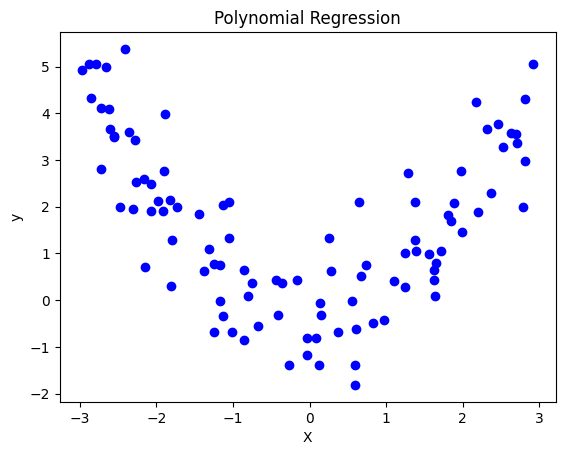

In [6]:
plt.scatter(X, y, color='blue')
plt.title('Polynomial Regression')
plt.xlabel('X')
plt.ylabel('y')
plt.show()

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
linear_model = LinearRegression()
linear_model.fit(X, y)
y_pred_linear = linear_model.predict(X)

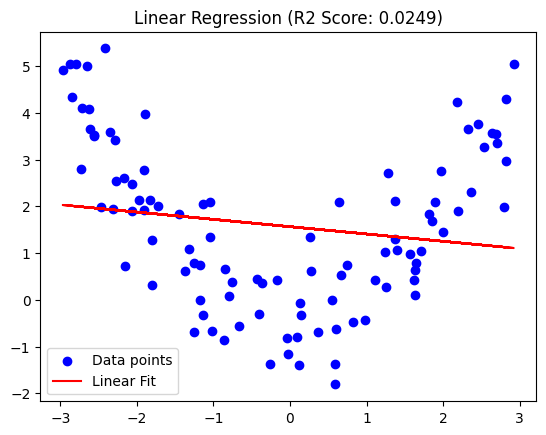

In [11]:
# Plot the straight line fit
plt.scatter(X, y, color='blue', label='Data points')
plt.plot(X, y_pred_linear, color='red', label='Linear Fit')
plt.title(f"Linear Regression (R2 Score: {r2_score(y, y_pred_linear):.4f})")
plt.legend()
plt.show()

In [13]:
from sklearn.preprocessing import PolynomialFeatures

poly_model = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly_model.fit_transform(X)

print("Original X[0] : ", X[0])
print("Transformed X_poly[0] (contains X and X^2):", X_poly[0])

Original X[0] :  [-0.75275929]
Transformed X_poly[0] (contains X and X^2): [-0.75275929  0.56664654]


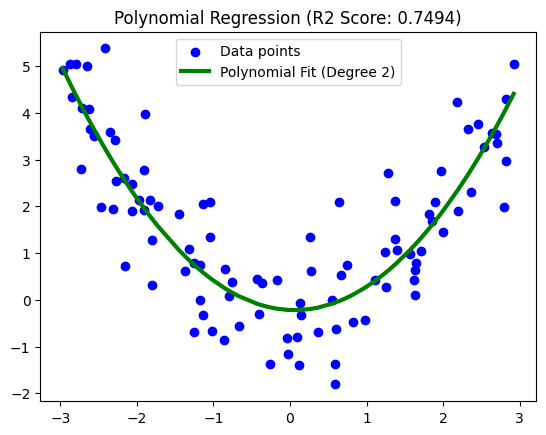

In [16]:
poly_reg = LinearRegression()
poly_reg.fit(X_poly, y)

y_pred_poly = poly_reg.predict(X_poly)

sort_axis = np.argsort(X.flatten())
X_sorted = X[sort_axis]
y_pred_poly_sorted = y_pred_poly[sort_axis]
# Plot the curved fit
plt.scatter(X, y, color='blue', label='Data points')
plt.plot(X_sorted, y_pred_poly_sorted, color='green', linewidth=3, label='Polynomial Fit (Degree 2)')
plt.title(f"Polynomial Regression (R2 Score: {r2_score(y, y_pred_poly):.4f})")
plt.legend()
plt.show()

In [18]:
print("--- Simple Linear Regression ---")
print(f"y = {linear_model.coef_[0][0]:.2f}x + {linear_model.intercept_[0]:.2f}")

print("\n--- Polynomial Regression (Degree 2) ---")
print(f"y = {poly_reg.coef_[0][1]:.2f}x² + {poly_reg.coef_[0][0]:.2f}x + {poly_reg.intercept_[0]:.2f}")


--- Simple Linear Regression ---
y = -0.16x + 1.56

--- Polynomial Regression (Degree 2) ---
y = 0.56x² + -0.07x + -0.22
